We are now going to use my top performing model, Random forest, to calculate the SHAP (Shapely Additive Predictions) to determine which genes were most informative in predicting the different disease classifications. This is better than just using random forests feature selections as it is specific for the patient. SHAP provides ranking of genes per patient whereas RF features are averages. First however lets just see what Random Forest predicts for the most informative genes. 

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
import joblib

## I can now load directly from src via my .toml file.
from src.data import remove_zero_variance, load_data
from sklearn.model_selection import train_test_split

## Get data
X_df, y_df = load_data()
## Load the training data
X_train, X_test, y_train, y_test = train_test_split(X_df, y_df, test_size = 0.2, stratify = y_df, random_state = 42)


Removing 267 zero-variance genes.


Lets dig into the best performing random forest model more.

Random Forest Confusion Matrix
[[60  0  0  0  0]
 [ 0 16  0  0  0]
 [ 0  0 30  0  0]
 [ 1  0  0 27  0]
 [ 0  0  0  0 27]]


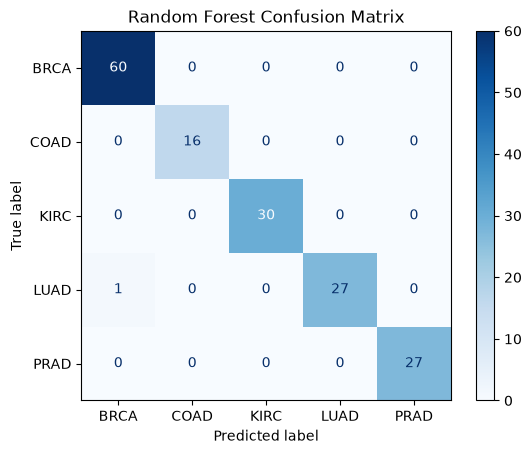

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
best_pipeline = joblib.load('../models/rf_best_model.pkl')
y_pred = best_pipeline.predict(X_test)
matrix = confusion_matrix(y_test, y_pred)
print("Random Forest Confusion Matrix")
print(matrix)

## Get disease lables
rf_model = best_pipeline.named_steps["classifier"]
disease_labels = rf_model.classes_
display = ConfusionMatrixDisplay(confusion_matrix=matrix, display_labels=disease_labels)
display.plot(cmap=plt.cm.Blues)
plt.title("Random Forest Confusion Matrix")
plt.show()

Oh wow, looks like the model only misclassified 1 instande of LUAD as BRCA. Next lets see what genes the Random forest used to make its predictions.

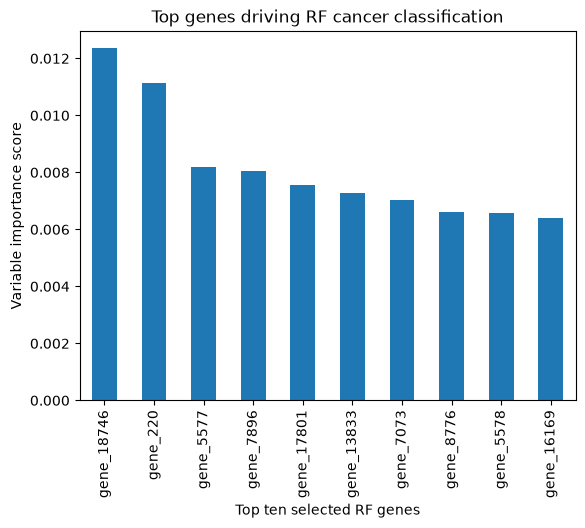

In [16]:


importances = pd.Series(rf_model.feature_importances_, index=X_df.columns)

sorted_importances = importances.sort_values(ascending = False)
top_ten_genes = sorted_importances.head(10)
top_gene = top_ten_genes.index[0]

top_ten_genes.plot.bar()
plt.xlabel("Top ten selected RF genes")
plt.ylabel("Variable importance score")
plt.title("Top genes driving RF cancer classification")
plt.show()

The following are the possible cancer classifications: ['BRCA' 'COAD' 'KIRC' 'LUAD' 'PRAD']
The predicted disease for patient 1 was KIRC


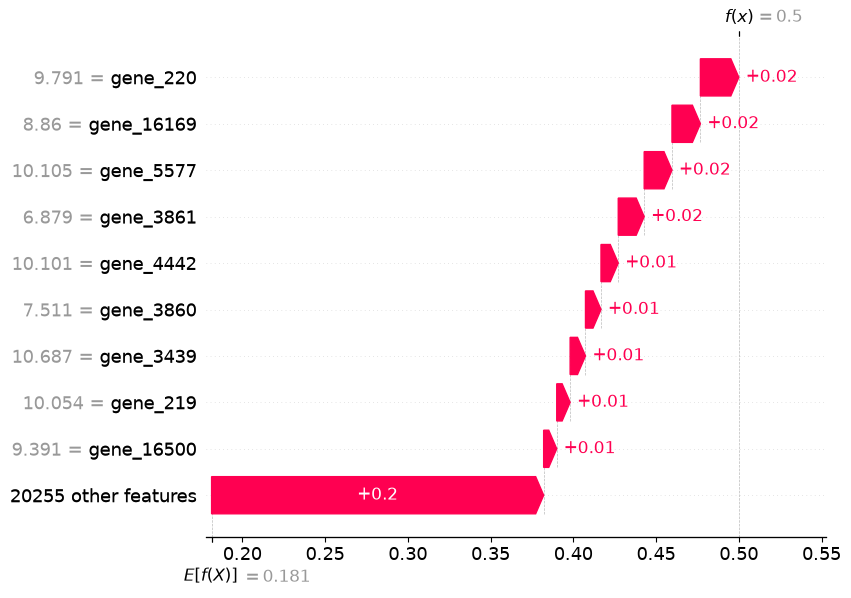

In [9]:
## Ok lets try using SHAP for this

import shap

print(f"The following are the possible cancer classifications: {rf_model.classes_}") 
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer(X_test)

## Ok for patient 1 what was the predicted disease type
pred_class = rf_model.predict(X_test.iloc[[0]])[0]
print(f"The predicted disease for patient 1 was {pred_class}")

## genes that most influenced the KIRK disease state prediction shown via a waterfall plot.
shap.plots.waterfall(shap_values[0, :, 2])

The above figure explains the random forest's prediction for a single patient. The model begins with an average predicted probability of KIRK based on the training data (E[f(x)] = 0.181). The waterfallplot shows the genes that increased the models confidence in the predicted cancer type up to f(x) = 0.5, the KIRK disease phenotype.

Now we can zoom out beyond an individual patient and show for across all patients, which genes pushed the tree to predicting a given disease. A beeswarm plot can give this disease type overview. Lets visualize genes informative for predicting BRCA disease.

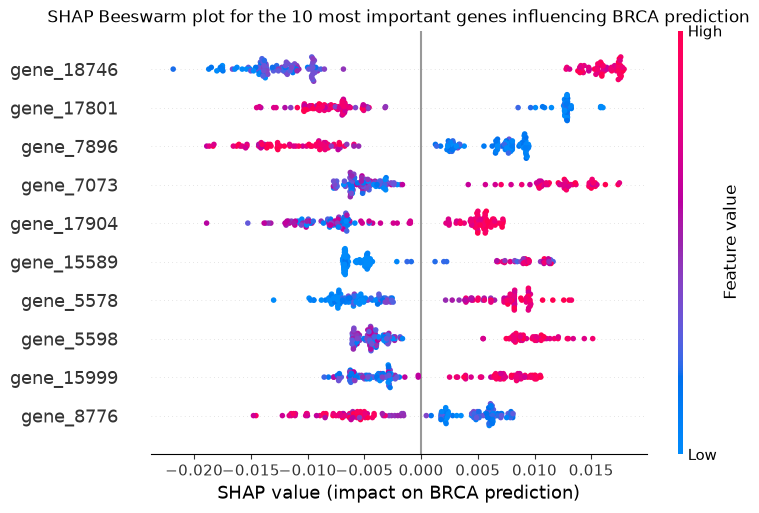

In [10]:
## Lets plot the BRCA beeplot
class_idx = list(rf_model.classes_).index("BRCA")
brca_shap = shap_values[:, :, class_idx]
shap.plots.beeswarm(
    brca_shap,
    max_display=10,
    group_remaining_features=False,
    show=False
)
plt.title('SHAP Beeswarm plot for the 10 most important genes influencing BRCA prediction')
plt.xlabel('SHAP value (impact on BRCA prediction)')
plt.show()

The beeswarm plot summarizes the influence of the 10 most informative genes for BRCA prediction across all patients. Each point represents one patient with color indicating the gene expression (red = higher expression). The highest ranked feature, gene_18746, predicted higher chance of BRCA cancer type with higher expression, while lower expression decreased BRCA prediction probability.